# VSL Extreme Low-Shot / One-Shot Recognition — Final Kaggle Notebook

**Target dataset:** `theait/vsl-vietnamese-sign-languages-full-videos-labels` — roughly 4K videos for roughly 3K Vietnamese sign glosses, with many classes having only 1–2 original videos.

This notebook is designed for the actual statistical regime of the dataset: **dictionary-scale isolated sign recognition with extreme one/few-shot supervision**, not a conventional 3000-way softmax classifier.

## Final pipeline

`Video → MediaPipe Holistic → signer/camera normalization → region-aware features (body / L-hand / R-hand / face + motion + hand geometry) → lightweight temporal encoder → contrastive + batch-hard metric learning → class prototypes → cosine Top-K → masked DTW reranking → UNKNOWN gate`

## Evaluation protocol used here

1. **Split ORIGINAL videos before augmentation**.
2. Reserve a set of multi-shot glosses as **UNSEEN classes**. The encoder never receives their labels or videos during training.
3. For each unseen gloss: one original video becomes **1-shot support**, remaining originals are queries. This directly tests whether the learned embedding can recognize classes never seen during training.
4. Remaining multi-shot classes have a normal seen-class validation split.
5. Single-video classes cannot have an independent same-class test; they remain training references and are only evaluated later with truly new external recordings.
6. UNKNOWN thresholds are calibrated with seen validation clips as known and held-out unseen-class clips as proxy OOV.

## Literature-driven design choices

- **Pose normalization + local hand coordinates + pose augmentation:** Boháček & Hrúz, *Sign Pose-Based Transformer for Word-Level Sign Language Recognition*, WACV Workshops 2022.
- **Embedding/contrastive learning for unseen/few-shot signs:** Ferreira et al., *A Transformer-Based Contrastive Learning Approach for Few-Shot Sign Language Recognition*, 2022.
- **Joint + first-order motion and hand/trunk complementary streams:** Zhao et al., *Self-Supervised Representation Learning with Spatial-Temporal Consistency for Sign Language Recognition*, IEEE TIP 2024.
- **Region-aware body/hand/face modeling:** recent ICCV/CVPR sign-language workshop work motivates separating articulators instead of flattening all points into one feature vector.
- **Hand geometry descriptors:** Chamachot & Lertniphonphan, CVPR Workshops 2026, supports geometry-invariant hand descriptors in few-shot settings. Their paper is static fingerspelling; this notebook uses the idea only as an auxiliary dynamic hand feature, not as a claimed direct reproduction.
- **Masked-keypoint DTW:** Ham2Pose (CVPR 2023) motivates distance measures that explicitly handle missing landmarks.
- **ViSL One-shot:** the 2024 ViSL work applies controlled skeleton variation to a 4,364-video Vietnamese corpus. Its reported >95% classification result comes from a separate 60-word Indian Sign Language experiment; this notebook does **not** assume that accuracy transfers to the full Vietnamese vocabulary.

No accuracy is claimed until you run the notebook on your actual Kaggle input.

> **Kaggle compatibility:** this build uses current `MediaPipe Tasks / HolisticLandmarker` and never downgrades NumPy, protobuf, pandas, or OpenCV. Use a fresh Kaggle session.

In [1]:
# ============================================================
# 0. Environment — current Kaggle compatible
# ============================================================
# Do NOT downgrade NumPy / protobuf / pandas / OpenCV.
# MediaPipe >= 0.10.30 removed legacy `mp.solutions`.
# This notebook uses the current MediaPipe Tasks API.
# ============================================================

import os, sys, json, math, random, hashlib, warnings, subprocess, importlib.util, urllib.request
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

def ensure_mediapipe_tasks():
    try:
        import mediapipe as _mp
        if hasattr(_mp, "tasks"):
            return _mp
    except Exception:
        pass

    # --no-deps prevents pip from replacing Kaggle's NumPy/protobuf stack.
    print("Installing MediaPipe Tasks wheel without dependency downgrades ...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "--no-deps", "mediapipe>=0.10.35,<0.11"
    ])

    for name in list(sys.modules):
        if name == "mediapipe" or name.startswith("mediapipe."):
            del sys.modules[name]

    import mediapipe as _mp
    return _mp

mp = ensure_mediapipe_tasks()
warnings.filterwarnings("ignore")

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("PyTorch:", torch.__version__)
print("MediaPipe:", getattr(mp, "__version__", "unknown"))
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

if not hasattr(mp, "tasks"):
    raise RuntimeError(
        "MediaPipe Tasks API is unavailable. Start a fresh Kaggle session and Run All."
    )

print("MediaPipe Tasks API: OK")

Installing MediaPipe Tasks wheel without dependency downgrades ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.5 MB/s eta 0:00:00
Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
OpenCV: 4.13.0
PyTorch: 2.10.0+cu128
MediaPipe: 0.10.35
CUDA: True
GPU: Tesla P100-PCIE-16GB
MediaPipe Tasks API: OK


In [2]:
# ============================================================
# 1. CENTRAL CONFIG — edit here first
# ============================================================
SEED = 42

# Dataset discovery
KAGGLE_INPUT = Path("/kaggle/input")
DATASET_HINT = "vsl-vietnamese-sign-languages-full-videos-labels"
MANUAL_DATA_ROOT = None       # e.g. "/kaggle/input/vsl-..."
MANUAL_LABEL_FILE = None      # .csv / .json / .xlsx if auto-discovery fails

# Current MediaPipe Tasks HolisticLandmarker model.
# If Kaggle Internet is OFF, upload holistic_landmarker.task as an Input.
HOLISTIC_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "holistic_landmarker/holistic_landmarker/float16/latest/holistic_landmarker.task"
)
MANUAL_HOLISTIC_MODEL = None  # e.g. "/kaggle/input/mediapipe-holistic/holistic_landmarker.task"


# Keypoints
SEQ_LEN = 48
MAX_RAW_FRAMES = 96
USE_FACE = True
MODEL_COMPLEXITY = 1
MIN_DET_CONF = 0.45
MIN_TRACK_CONF = 0.45

# Evaluation protocol
UNSEEN_EVAL_MAX_CLASSES = 100
UNSEEN_EVAL_FRACTION = 0.15   # fraction among classes having >=2 videos
SEEN_VAL_FRACTION = 0.20
UNSEEN_SUPPORT_PER_CLASS = 1

# Augmentation — intentionally mild
TEMP_SPEED_MIN = 0.85
TEMP_SPEED_MAX = 1.15
TEMP_CROP_MIN_KEEP = 0.85
ROT_DEG = 5.0
SCALE_MIN = 0.94
SCALE_MAX = 1.06
TRANSLATE_STD = 0.015
KEYPOINT_NOISE_STD = 0.006
FRAME_DROP_MAX = 0.07
POINT_DROP_PROB = 0.005

# Model
REGION_DIM = 96
D_MODEL = 256
NHEAD = 8
NUM_TRANSFORMER_LAYERS = 3
FF_DIM = 512
DROPOUT = 0.12
EMBED_DIM = 256
USE_HAND_ANGLE_FEATURES = True

# Optional self-supervised warm-up on TRAIN VIDEOS ONLY
SELF_SUP_EPOCHS = 3
SELF_SUP_BATCH = 96
SELF_SUP_TEMP = 0.10

# Metric-learning stage
PK_P = 24                 # labels per batch
PK_K = 2                  # samples/views per label; replacement allowed for one-shot labels
BATCHES_PER_EPOCH = 220
METRIC_EPOCHS = 25
LR = 3e-4
WEIGHT_DECAY = 1e-4
SUPCON_TEMP = 0.07
TRIPLET_MARGIN = 0.20
TRIPLET_WEIGHT = 0.20
GRAD_ACCUM_STEPS = 1
MAX_GRAD_NORM = 1.0

# Kaggle notebook stability
NUM_WORKERS = 0            # avoid QueueFeederThread / bad file descriptor issues
SSL_FORCE_FP32 = True      # SSL is short; FP32 is safer than T4 float16 here
COORD_CLIP = 8.0           # clip body-normalized coordinates after robust normalization
LOCAL_HAND_CLIP = 6.0      # clip wrist-relative hand coordinates
MIN_SHOULDER_SCALE = 0.08  # prevents exploding coords on bad shoulder detections
MIN_HAND_SCALE = 0.04

# MediaPipe Tasks VIDEO mode requires timestamps to increase across ALL
# detect_for_video() calls made by the same landmarker instance.
# Give each source video its own large timestamp window.
VIDEO_TIMESTAMP_STRIDE_MS = 1_000_000  # ~16.7 min per video slot
      # prevents exploding local-hand coords


# Prototype / rerank
STABILIZED_PROTO_AUGS = 4
DTW_TOPK = 7
COSINE_WEIGHT = 0.78
DTW_WEIGHT = 0.22

# UNKNOWN fallback values. The notebook will calibrate better values when possible.
DEFAULT_UNKNOWN_COS = 0.55
DEFAULT_UNKNOWN_MARGIN = 0.02

# Export
EXPORT_ONNX = False

WORK_DIR = Path("/kaggle/working/vsl_lowshot_final")
FEATURE_DIR = WORK_DIR / "features"
EXPORT_DIR = WORK_DIR / "export"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)
print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
# ============================================================
# 1b. HolisticLandmarker model asset
# ============================================================
def find_holistic_model():
    if MANUAL_HOLISTIC_MODEL:
        p = Path(MANUAL_HOLISTIC_MODEL)
        if not p.exists():
            raise FileNotFoundError(p)
        return p

    # Prefer a model already attached as Kaggle Input.
    if KAGGLE_INPUT.exists():
        hits = list(KAGGLE_INPUT.rglob("holistic_landmarker.task"))
        if hits:
            print("Using model from Kaggle Input:", hits[0])
            return hits[0]

    # Otherwise download the official MediaPipe model.
    p = WORK_DIR / "holistic_landmarker.task"
    if not p.exists():
        print("Downloading official HolisticLandmarker model ...")
        try:
            urllib.request.urlretrieve(HOLISTIC_MODEL_URL, p)
        except Exception as e:
            raise RuntimeError(
                "Could not download holistic_landmarker.task. "
                "Enable Kaggle Internet OR upload the model as a Kaggle Input "
                "and set MANUAL_HOLISTIC_MODEL."
            ) from e
    return p

HOLISTIC_MODEL_PATH = find_holistic_model()
print("HOLISTIC_MODEL_PATH:", HOLISTIC_MODEL_PATH)
print("Model size MB:", round(HOLISTIC_MODEL_PATH.stat().st_size / 1024**2, 2))

HOLISTIC_MODEL_PATH: /kaggle/working/vsl_lowshot_final/holistic_landmarker.task
Model size MB: 13.05


## 2. Dataset discovery and audit

The cell below handles common Kaggle layouts:

- `root/<gloss>/*.mp4`
- CSV/XLSX with a video/path column and a label/gloss column
- JSON `filename → label` or list-of-records

If auto-detection chooses the wrong file, set `MANUAL_DATA_ROOT` / `MANUAL_LABEL_FILE` in the config cell.

In [4]:
# ============================================================
# 2. Dataset discovery
# ============================================================
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".mpeg", ".mpg", ".m4v"}
PATH_COL_CANDIDATES = [
    "path", "filepath", "file_path", "video", "video_path", "filename",
    "file", "name", "video_name", "clip", "clip_path"
]
LABEL_COL_CANDIDATES = [
    "label", "gloss", "word", "class", "class_name", "category",
    "text", "meaning", "vietnamese", "translation"
]


def _norm_col(s):
    return str(s).strip().lower().replace(" ", "_").replace("-", "_")


def find_dataset_root():
    if MANUAL_DATA_ROOT:
        root = Path(MANUAL_DATA_ROOT)
        if not root.exists():
            raise FileNotFoundError(root)
        return root

    if not KAGGLE_INPUT.exists():
        raise FileNotFoundError("/kaggle/input not found. Run this notebook on Kaggle or set MANUAL_DATA_ROOT.")

    dirs = [p for p in KAGGLE_INPUT.iterdir() if p.is_dir()]
    hinted = [p for p in dirs if DATASET_HINT.lower() in p.name.lower()]
    if hinted:
        return hinted[0]

    scored = []
    for d in dirs:
        n = sum(1 for p in d.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS)
        scored.append((n, d))
    scored.sort(key=lambda z: z[0], reverse=True)
    if scored and scored[0][0] > 0:
        print("DATASET_HINT not matched; selecting input folder with most videos.")
        return scored[0][1]
    raise FileNotFoundError("No video dataset found under /kaggle/input")


DATA_ROOT = find_dataset_root()
all_videos = sorted(p for p in DATA_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTS)
print("DATA_ROOT:", DATA_ROOT)
print("Video count:", len(all_videos))
for p in all_videos[:10]:
    print(" -", p.relative_to(DATA_ROOT))

DATASET_HINT not matched; selecting input folder with most videos.
DATA_ROOT: /kaggle/input/datasets
Video count: 4362
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0001B.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0001N.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0001T.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0002.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0003.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0004.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0005B.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0005N.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0005T.mp4
 - theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Videos/D0006.mp4


In [5]:
# ============================================================
# 3. Label discovery
# ============================================================
def make_name_index(videos):
    by_name = defaultdict(list)
    by_stem = defaultdict(list)
    for v in videos:
        by_name[v.name].append(v)
        by_stem[v.stem].append(v)
    return by_name, by_stem

BY_NAME, BY_STEM = make_name_index(all_videos)


def resolve_video_path(raw, root):
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return None
    s = str(raw).strip().replace("\\", "/")
    if not s:
        return None
    p = Path(s)
    candidates = [root / p, root / p.name]
    for c in candidates:
        if c.exists() and c.suffix.lower() in VIDEO_EXTS:
            return c
    if len(BY_NAME.get(p.name, [])) == 1:
        return BY_NAME[p.name][0]
    if len(BY_STEM.get(p.stem, [])) == 1:
        return BY_STEM[p.stem][0]
    return None


def dataframe_to_samples(df, source):
    cmap = {_norm_col(c): c for c in df.columns}
    pcol = next((cmap[c] for c in PATH_COL_CANDIDATES if c in cmap), None)
    lcol = next((cmap[c] for c in LABEL_COL_CANDIDATES if c in cmap), None)
    if pcol is None or lcol is None:
        return None
    rows = []
    for _, r in df.iterrows():
        vp = resolve_video_path(r[pcol], DATA_ROOT)
        if vp is not None and pd.notna(r[lcol]):
            rows.append({
                "video_path": str(vp),
                "label": str(r[lcol]).strip(),
                "label_source": str(source),
            })
    return pd.DataFrame(rows) if rows else None


def parse_table(path):
    try:
        if path.suffix.lower() == ".csv":
            return dataframe_to_samples(pd.read_csv(path), path)
        if path.suffix.lower() in {".xlsx", ".xls"}:
            return dataframe_to_samples(pd.read_excel(path), path)
    except Exception:
        return None
    return None


def parse_json(path):
    obj = None
    for enc in ("utf-8", "utf-8-sig"):
        try:
            obj = json.loads(path.read_text(encoding=enc))
            break
        except Exception:
            pass
    if obj is None:
        return None

    rows = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, (str, int, float)):
                vp = resolve_video_path(k, DATA_ROOT)
                if vp is not None:
                    rows.append({"video_path": str(vp), "label": str(v).strip(), "label_source": str(path)})
    elif isinstance(obj, list):
        try:
            return dataframe_to_samples(pd.DataFrame(obj), path)
        except Exception:
            return None
    return pd.DataFrame(rows) if rows else None


def discover_samples():
    if MANUAL_LABEL_FILE:
        p = Path(MANUAL_LABEL_FILE)
        out = parse_json(p) if p.suffix.lower() == ".json" else parse_table(p)
        if out is None:
            raise RuntimeError("Could not parse MANUAL_LABEL_FILE")
        return out

    for p in list(sorted(DATA_ROOT.rglob("*.csv"))) + list(sorted(DATA_ROOT.rglob("*.xlsx"))):
        out = parse_table(p)
        if out is not None and len(out) >= max(10, int(0.5 * len(all_videos))):
            print("Using label table:", p)
            return out

    for p in sorted(DATA_ROOT.rglob("*.json")):
        out = parse_json(p)
        if out is not None and len(out) >= max(10, int(0.5 * len(all_videos))):
            print("Using label JSON:", p)
            return out

    parents = [v.parent.name for v in all_videos]
    if len(set(parents)) >= 2:
        print("No suitable label file found; using parent folder as gloss.")
        return pd.DataFrame({
            "video_path": [str(v) for v in all_videos],
            "label": parents,
            "label_source": "parent_folder",
        })

    raise RuntimeError("Could not infer labels. Inspect DATA_ROOT and set MANUAL_LABEL_FILE.")


samples_df = discover_samples().drop_duplicates("video_path").reset_index(drop=True)
samples_df["label"] = samples_df["label"].astype(str).str.strip()
samples_df = samples_df[samples_df["label"].ne("")].reset_index(drop=True)

counts = samples_df["label"].value_counts()
print("Labeled videos:", len(samples_df))
print("Unique glosses:", samples_df["label"].nunique())
print("One-shot glosses:", int((counts == 1).sum()))
print("Multi-shot glosses:", int((counts >= 2).sum()))
display(samples_df.head(10))
display(counts.describe().to_frame("videos_per_gloss"))

Using label table: /kaggle/input/datasets/theait/vsl-vietnamese-sign-languages-full-videos-labels/Dataset/Labels/label.csv
Labeled videos: 4362
Unique glosses: 3315
One-shot glosses: 2765
Multi-shot glosses: 550


,video_path,label,label_source
0,/kaggle/input/datasets/theait/vsl-vietnamese-s...,địa chỉ,/kaggle/input/datasets/theait/vsl-vietnamese-s...
1,/kaggle/input/datasets/theait/vsl-vietnamese-s...,địa chỉ,/kaggle/input/datasets/theait/vsl-vietnamese-s...
2,/kaggle/input/datasets/theait/vsl-vietnamese-s...,địa chỉ,/kaggle/input/datasets/theait/vsl-vietnamese-s...
3,/kaggle/input/datasets/theait/vsl-vietnamese-s...,tỉnh,/kaggle/input/datasets/theait/vsl-vietnamese-s...
4,/kaggle/input/datasets/theait/vsl-vietnamese-s...,nhân viên,/kaggle/input/datasets/theait/vsl-vietnamese-s...
5,/kaggle/input/datasets/theait/vsl-vietnamese-s...,tiếp tân,/kaggle/input/datasets/theait/vsl-vietnamese-s...
6,/kaggle/input/datasets/theait/vsl-vietnamese-s...,Miến Điện (nước Mi-an-ma),/kaggle/input/datasets/theait/vsl-vietnamese-s...
7,/kaggle/input/datasets/theait/vsl-vietnamese-s...,Ma Cao,/kaggle/input/datasets/theait/vsl-vietnamese-s...
8,/kaggle/input/datasets/theait/vsl-vietnamese-s...,Do Thái,/kaggle/input/datasets/theait/vsl-vietnamese-s...
9,/kaggle/input/datasets/theait/vsl-vietnamese-s...,Ả Rập (nước Ả Rập),/kaggle/input/datasets/theait/vsl-vietnamese-s...


,videos_per_gloss
count,3315.000000
mean,1.315837
std,0.722999
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,6.000000


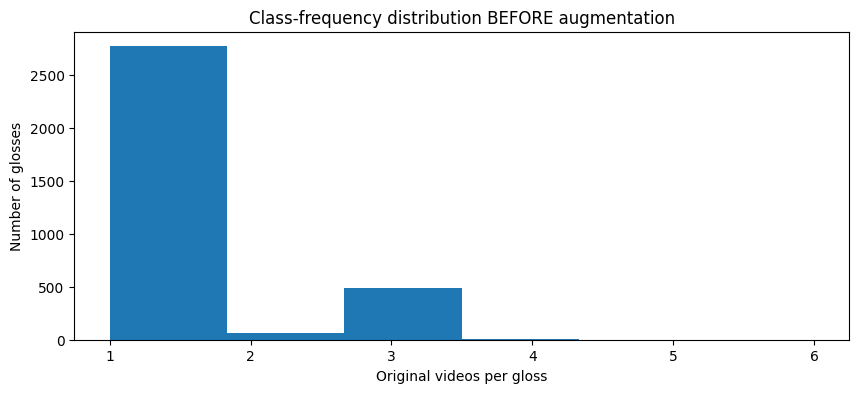

,videos_per_gloss,num_glosses
0,1,2765
1,2,61
2,3,483
3,4,5
4,6,1


In [6]:
# ============================================================
# 4. Audit plots
# ============================================================
plt.figure(figsize=(10, 4))
plt.hist(counts.values, bins=min(30, max(5, int(counts.max()))))
plt.xlabel("Original videos per gloss")
plt.ylabel("Number of glosses")
plt.title("Class-frequency distribution BEFORE augmentation")
plt.show()

freq_table = pd.DataFrame({
    "videos_per_gloss": sorted(counts.unique()),
    "num_glosses": [int((counts == n).sum()) for n in sorted(counts.unique())],
})
display(freq_table.head(20))

## 5. MediaPipe feature representation

Stored cache format is `[T, P, 4] = (x, y, z, visible)` rather than a single flat vector.

- Pose: 33 landmarks
- Left hand: 21
- Right hand: 21
- Face: a compact 40-point subset around lips/eyes/eyebrows

Keeping the structured layout lets the model use **separate region encoders**, local hand coordinates, first-order motion, and geometry features.

In [7]:
# ============================================================
# 5. MediaPipe Tasks landmark specification
# ============================================================

BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode

try:
    HolisticLandmarker = mp.tasks.vision.HolisticLandmarker
    HolisticLandmarkerOptions = mp.tasks.vision.HolisticLandmarkerOptions
except AttributeError:
    from mediapipe.tasks.python.vision.holistic_landmarker import (
        HolisticLandmarker,
        HolisticLandmarkerOptions,
    )

FACE_IDX = [
    61,146,91,181,84,17,314,405,321,375,291,
    78,95,88,178,87,14,317,402,318,324,308,
    33,133,159,145,362,263,386,374,
    70,63,105,66,107,336,296,334,293,300,
]

N_POSE = 33
N_HAND = 21
N_FACE = len(FACE_IDX) if USE_FACE else 0
N_POINTS = N_POSE + 2 * N_HAND + N_FACE
POINT_DIM = 4

POSE_SLICE = slice(0, N_POSE)
LH_SLICE = slice(N_POSE, N_POSE + N_HAND)
RH_SLICE = slice(N_POSE + N_HAND, N_POSE + 2*N_HAND)
FACE_SLICE = slice(N_POSE + 2*N_HAND, N_POINTS)

BODY_IDS = torch.tensor([0, 11, 12, 13, 14, 15, 16, 23, 24], dtype=torch.long)

def create_holistic_landmarker():
    options = HolisticLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(HOLISTIC_MODEL_PATH)),
        running_mode=VisionRunningMode.VIDEO,
        min_face_detection_confidence=MIN_DET_CONF,
        min_face_landmarks_confidence=MIN_TRACK_CONF,
        min_pose_detection_confidence=MIN_DET_CONF,
        min_pose_landmarks_confidence=MIN_TRACK_CONF,
        min_hand_landmarks_confidence=MIN_TRACK_CONF,
        output_face_blendshapes=False,
        output_segmentation_mask=False,
    )
    return HolisticLandmarker.create_from_options(options)

print({
    "points": N_POINTS,
    "seq_len": SEQ_LEN,
    "use_face": USE_FACE,
    "mediapipe_api": "Tasks/HolisticLandmarker",
})

{'points': 115, 'seq_len': 48, 'use_face': True, 'mediapipe_api': 'Tasks/HolisticLandmarker'}


In [8]:
# ============================================================
# 6. Extract structured landmarks from video — MediaPipe Tasks
# ============================================================
def uniform_frame_indices(frame_count, max_frames):
    if frame_count <= 0:
        return None
    n = min(frame_count, max_frames)
    return np.unique(np.linspace(0, frame_count - 1, n).round().astype(int))


def landmarks_to_array(landmarks, expected_n, selected_idx=None):
    arr = np.zeros((expected_n, 4), dtype=np.float32)

    if landmarks is None:
        return arr

    lms = landmarks.landmark if hasattr(landmarks, "landmark") else landmarks
    if len(lms) == 0:
        return arr

    idxs = range(min(expected_n, len(lms))) if selected_idx is None else selected_idx

    for out_i, lm_i in enumerate(idxs):
        if out_i >= expected_n or lm_i >= len(lms):
            break
        lm = lms[lm_i]
        arr[out_i, :3] = (float(lm.x), float(lm.y), float(lm.z))
        arr[out_i, 3] = 1.0

    return arr


def extract_raw_keypoints(video_path, holistic, timestamp_base_ms=0):
    """
    IMPORTANT:
    The same HolisticLandmarker is reused for many source videos.
    In VIDEO mode, MediaPipe requires timestamps to be monotonically
    increasing across adjacent detect_for_video() calls.

    Therefore each source video receives a unique timestamp_base_ms.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    if not np.isfinite(fps) or fps <= 1e-6:
        fps = 30.0

    wanted = uniform_frame_indices(frame_count, MAX_RAW_FRAMES)
    wanted_set = set(wanted.tolist()) if wanted is not None else None

    seq = []
    fi = 0
    last_ts = int(timestamp_base_ms) - 1

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if wanted_set is not None and fi not in wanted_set:
            fi += 1
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=np.ascontiguousarray(rgb)
        )

        relative_ms = int(round(fi * 1000.0 / fps))
        timestamp_ms = int(timestamp_base_ms) + relative_ms

        # Absolute safety for codecs with odd FPS/frame metadata.
        if timestamp_ms <= last_ts:
            timestamp_ms = last_ts + 1
        last_ts = timestamp_ms

        result = holistic.detect_for_video(mp_image, timestamp_ms)

        pose = landmarks_to_array(result.pose_landmarks, N_POSE)
        lh = landmarks_to_array(result.left_hand_landmarks, N_HAND)
        rh = landmarks_to_array(result.right_hand_landmarks, N_HAND)

        parts = [pose, lh, rh]
        if USE_FACE:
            face = landmarks_to_array(result.face_landmarks, N_FACE, FACE_IDX)
            parts.append(face)

        seq.append(np.concatenate(parts, axis=0))
        fi += 1

    cap.release()

    if len(seq) == 0:
        raise RuntimeError(f"No readable frames: {video_path}")

    return np.stack(seq).astype(np.float32)

## 7. Normalization

The normalization keeps sign location relative to the body while removing nuisance camera variation:

- center around shoulder midpoint;
- scale by shoulder distance;
- apply one robust sequence-level shoulder orientation rotation so camera roll does not become a class cue;
- retain missing-point masks.

Hands are additionally converted to **wrist-relative local coordinates inside the neural network**, while their body-relative global coordinates are also preserved. This intentionally keeps both *handshape* and *signing-space location*.

In [9]:
# ============================================================
# 7. Normalize and resample — numerically robust
# ============================================================
def sanitize_sequence(x, coord_clip=None):
    x = np.asarray(x, dtype=np.float32).copy()
    # MediaPipe can rarely emit NaN/Inf for unstable landmarks.
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    # Visibility/presence mask must stay bounded.
    x[..., 3] = np.clip(x[..., 3], 0.0, 1.0)

    if coord_clip is not None:
        x[..., :3] = np.clip(x[..., :3], -coord_clip, coord_clip)

    # Missing points must not retain coordinates.
    x[..., :3] *= (x[..., 3:4] > 1e-6).astype(np.float32)
    return x


def normalize_skeleton(seq):
    x = sanitize_sequence(seq)
    xyz = x[..., :3]
    mask = x[..., 3:4]

    # shoulders: MediaPipe Pose 11 and 12
    shoulder_valid = (
        (x[:, 11, 3] > 0.5)
        & (x[:, 12, 3] > 0.5)
        & np.isfinite(x[:, 11, :3]).all(axis=1)
        & np.isfinite(x[:, 12, :3]).all(axis=1)
    )

    global_center = None
    global_scale = None
    theta = 0.0

    if shoulder_valid.any():
        centers = (xyz[shoulder_valid, 11] + xyz[shoulder_valid, 12]) / 2.0
        dists = np.linalg.norm(
            xyz[shoulder_valid, 11, :2] - xyz[shoulder_valid, 12, :2],
            axis=1
        )

        # Reject obviously broken shoulder distances.
        good_d = np.isfinite(dists) & (dists >= MIN_SHOULDER_SCALE) & (dists <= 1.5)

        if good_d.any():
            global_center = np.median(centers[good_d], axis=0)
            global_scale = float(np.median(dists[good_d]))

            shoulder_vec = (
                xyz[shoulder_valid, 12, :2] - xyz[shoulder_valid, 11, :2]
            )[good_d]
            angles = np.arctan2(shoulder_vec[:, 1], shoulder_vec[:, 0])
            angles = angles[np.isfinite(angles)]
            if len(angles):
                theta = -float(np.median(angles))

    # Robust fallback if shoulders are missing / unreliable.
    if global_center is None or global_scale is None or not np.isfinite(global_scale):
        vis = mask[..., 0] > 0.5
        pts = xyz[vis]

        if len(pts) == 0:
            return sanitize_sequence(x, COORD_CLIP)

        global_center = np.median(pts, axis=0)
        radial = np.linalg.norm(pts[:, :2] - global_center[:2], axis=1)
        radial = radial[np.isfinite(radial) & (radial > 1e-4)]

        # A conservative fallback: body-space scale should never be tiny.
        global_scale = float(np.median(radial)) if len(radial) else 0.25

    global_scale = float(np.clip(global_scale, MIN_SHOULDER_SCALE, 2.0))

    # Frame-local shoulder center only when reliable.
    centers_t = np.repeat(global_center[None], len(x), axis=0)
    if shoulder_valid.any():
        local_centers = (xyz[shoulder_valid, 11] + xyz[shoulder_valid, 12]) / 2.0
        centers_t[shoulder_valid] = local_centers

    xyz = (xyz - centers_t[:, None, :]) / global_scale

    # One robust sequence-level rotation.
    if np.isfinite(theta):
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([[c, -s], [s, c]], dtype=np.float32)
        xyz[..., :2] = xyz[..., :2] @ R.T

    xyz *= mask
    x[..., :3] = xyz

    # Critical: finite + clipping prevents FP16 overflow later.
    return sanitize_sequence(x, COORD_CLIP)


def resample_sequence(seq, target_len=48):
    seq = sanitize_sequence(seq, COORD_CLIP)

    if len(seq) == target_len:
        return seq.astype(np.float32)

    if len(seq) == 1:
        return np.repeat(seq, target_len, axis=0).astype(np.float32)

    old_t = np.linspace(0.0, 1.0, len(seq))
    new_t = np.linspace(0.0, 1.0, target_len)

    flat = seq.reshape(len(seq), -1)
    out = np.empty((target_len, flat.shape[1]), dtype=np.float32)

    for j in range(flat.shape[1]):
        out[:, j] = np.interp(new_t, old_t, flat[:, j])

    out = out.reshape(target_len, seq.shape[1], seq.shape[2])
    return sanitize_sequence(out, COORD_CLIP)


def process_video(video_path, holistic, timestamp_base_ms=0):
    raw = extract_raw_keypoints(
        video_path,
        holistic,
        timestamp_base_ms=timestamp_base_ms
    )
    norm = normalize_skeleton(raw)
    out = resample_sequence(norm, SEQ_LEN)
    return sanitize_sequence(out, COORD_CLIP)

### MediaPipe VIDEO-mode timestamp note

`HolisticLandmarker.detect_for_video()` requires timestamps to increase monotonically
for consecutive calls on the same landmarker instance.

Because this notebook reuses one landmarker across thousands of independent source
videos, every video is assigned its own timestamp window:

`timestamp = video_index × VIDEO_TIMESTAMP_STRIDE_MS + frame_time_ms`

This avoids the failure mode where only the first video extracts successfully and all
later videos fail when their timestamps restart from zero.

In [10]:
# ============================================================
# 8. Feature extraction + per-video cache
# ============================================================
def cache_path_for(video_path):
    rel = str(Path(video_path).relative_to(DATA_ROOT))
    return FEATURE_DIR / f"{hashlib.md5(rel.encode('utf-8')).hexdigest()}.npz"

records, errors = [], []

# Reuse ONE model instance for speed.
# Each source video gets a disjoint timestamp window so VIDEO mode remains valid.
with create_holistic_landmarker() as holistic:
    for video_ord, row in enumerate(
        tqdm(
            samples_df.itertuples(index=False),
            total=len(samples_df),
            desc="MediaPipe Tasks"
        )
    ):
        vp = Path(row.video_path)
        cp = cache_path_for(vp)

        try:
            if cp.exists():
                seq = np.load(cp, allow_pickle=True)["sequence"].astype(np.float32)
            else:
                timestamp_base_ms = int(video_ord) * int(VIDEO_TIMESTAMP_STRIDE_MS)

                seq = process_video(
                    vp,
                    holistic,
                    timestamp_base_ms=timestamp_base_ms
                )

                np.savez_compressed(
                    cp,
                    sequence=seq.astype(np.float16),
                    label=str(row.label),
                    video_path=str(vp),
                )

            records.append({
                "video_path": str(vp),
                "label": str(row.label),
                "cache_path": str(cp),
            })

        except Exception as e:
            errors.append({
                "video_path": str(vp),
                "label": str(row.label),
                "error": repr(e),
            })

features_index = pd.DataFrame(records)
errors_df = pd.DataFrame(errors)

print("Extracted:", len(features_index), "Errors:", len(errors_df))

if len(errors_df):
    print("\nMost common extraction errors:")
    display(
        errors_df["error"]
        .value_counts()
        .head(10)
        .rename_axis("error")
        .reset_index(name="count")
    )
    display(errors_df.head(20))
    errors_df.to_csv(WORK_DIR / "extraction_errors.csv", index=False)

# Hard fail if extraction is clearly broken instead of silently continuing
# to training with only a handful of videos.
success_rate = len(features_index) / max(1, len(samples_df))
print(f"Extraction success rate: {success_rate:.2%}")

if success_rate < 0.90:
    raise RuntimeError(
        f"Feature extraction success rate is only {success_rate:.2%}. "
        "Inspect extraction_errors.csv before training."
    )

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786537443.186131      68 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786537443.224796      68 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786537443.230816      68 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786537443.230952      65 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786537443.234067      67 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786537443.265789     

MediaPipe Tasks:   0%|          | 0/4362 [00:00<?, ?it/s]

W0000 00:00:1786537443.511233      67 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Extracted: 4362 Errors: 0
Extraction success rate: 100.00%


In [11]:
# ============================================================
# 9. Consolidate cache
# ============================================================
X, labels_str, video_paths = [], [], []
for r in tqdm(features_index.itertuples(index=False), total=len(features_index), desc="Load cache"):
    d = np.load(r.cache_path, allow_pickle=True)
    X.append(d["sequence"].astype(np.float32))
    labels_str.append(str(r.label))
    video_paths.append(str(r.video_path))

X = np.stack(X).astype(np.float32)                  # [N,T,P,4]
labels_str = np.asarray(labels_str, dtype=object)
video_paths = np.asarray(video_paths, dtype=object)

unique_labels = sorted(set(labels_str.tolist()))
label_to_id = {lab: i for i, lab in enumerate(unique_labels)}
id_to_label = {i: lab for lab, i in label_to_id.items()}
y = np.asarray([label_to_id[x] for x in labels_str], dtype=np.int64)

np.savez_compressed(
    WORK_DIR / "vsl_keypoints.npz",
    X=X.astype(np.float16), y=y, labels_str=labels_str, video_paths=video_paths,
)
(EXPORT_DIR / "labels.json").write_text(
    json.dumps({"label_to_id": label_to_id, "id_to_label": {str(k): v for k, v in id_to_label.items()}}, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("X:", X.shape, "labels:", len(unique_labels))

Load cache:   0%|          | 0/4362 [00:00<?, ?it/s]

X: (4362, 48, 115, 4) labels: 3315


In [12]:
# ============================================================
# 9b. Numerical audit — MUST pass before splitting/training
# ============================================================
print("Auditing cached keypoints ...")

bad_sample_mask = ~np.isfinite(X).reshape(len(X), -1).all(axis=1)
n_bad = int(bad_sample_mask.sum())

max_abs_before = float(np.nanmax(np.abs(X[..., :3]))) if len(X) else 0.0
print("Non-finite samples before sanitize:", n_bad)
print("Max |coordinate| before sanitize:", max_abs_before)

# Clean old caches too, so this notebook can safely continue even if the
# extraction cache came from a previous run.
X = np.nan_to_num(X.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
X[..., 3] = np.clip(X[..., 3], 0.0, 1.0)
X[..., :3] = np.clip(X[..., :3], -COORD_CLIP, COORD_CLIP)
X[..., :3] *= (X[..., 3:4] > 1e-6).astype(np.float32)

assert np.isfinite(X).all(), "X still contains NaN/Inf after sanitization"

max_abs_after = float(np.max(np.abs(X[..., :3]))) if len(X) else 0.0
print("Max |coordinate| after sanitize:", max_abs_after)
print("Finite audit: PASS")

# Overwrite consolidated safe feature file.
np.savez_compressed(
    WORK_DIR / "vsl_keypoints_safe.npz",
    X=X.astype(np.float16),
    y=y,
    labels_str=labels_str,
    video_paths=video_paths,
)

Auditing cached keypoints ...
Non-finite samples before sanitize: 0
Max |coordinate| before sanitize: 8.0
Max |coordinate| after sanitize: 8.0
Finite audit: PASS


## 10. Leakage-safe seen / unseen protocol

This is the most important evaluation change versus a normal random split.

- **Unseen evaluation glosses** must have at least two original videos.
- The entire gloss is excluded from representation training.
- One original clip is support, remaining clips are query.
- This estimates whether the encoder can support a new dictionary gloss from one example.

For seen classes, augmentation happens only after the original-video split.

In [13]:
# ============================================================
# 10. Seen / unseen split
# ============================================================
rng = np.random.default_rng(SEED)
label_to_indices = {int(l): np.where(y == l)[0] for l in np.unique(y)}
multi_labels = np.array([l for l, idx in label_to_indices.items() if len(idx) >= 2], dtype=np.int64)

n_unseen = min(
    UNSEEN_EVAL_MAX_CLASSES,
    max(1, int(round(len(multi_labels) * UNSEEN_EVAL_FRACTION))) if len(multi_labels) else 0,
)
unseen_labels = set(rng.choice(multi_labels, size=n_unseen, replace=False).tolist()) if n_unseen else set()

train_idx, seen_val_idx = [], []
unseen_support_idx, unseen_query_idx = [], []
one_shot_train_labels = []

for lab, idxs0 in label_to_indices.items():
    idxs = rng.permutation(idxs0)

    if lab in unseen_labels:
        unseen_support_idx.extend(idxs[:UNSEEN_SUPPORT_PER_CLASS].tolist())
        unseen_query_idx.extend(idxs[UNSEEN_SUPPORT_PER_CLASS:].tolist())
        continue

    if len(idxs) == 1:
        train_idx.extend(idxs.tolist())
        one_shot_train_labels.append(lab)
        continue

    n_val = max(1, int(round(len(idxs) * SEEN_VAL_FRACTION)))
    n_val = min(n_val, len(idxs)-1)
    seen_val_idx.extend(idxs[:n_val].tolist())
    train_idx.extend(idxs[n_val:].tolist())

train_idx = np.asarray(train_idx, np.int64)
seen_val_idx = np.asarray(seen_val_idx, np.int64)
unseen_support_idx = np.asarray(unseen_support_idx, np.int64)
unseen_query_idx = np.asarray(unseen_query_idx, np.int64)

sets = [set(a.tolist()) for a in [train_idx, seen_val_idx, unseen_support_idx, unseen_query_idx]]
for i in range(len(sets)):
    for j in range(i+1, len(sets)):
        assert sets[i].isdisjoint(sets[j]), (i, j, "split leakage")

print("Train original videos:", len(train_idx))
print("Seen validation videos:", len(seen_val_idx))
print("Unseen support videos:", len(unseen_support_idx))
print("Unseen query videos:", len(unseen_query_idx))
print("Held-out unseen glosses:", len(unseen_labels))
print("One-shot train-only glosses:", len(one_shot_train_labels))

Train original videos: 3655
Seen validation videos: 468
Unseen support videos: 82
Unseen query videos: 157
Held-out unseen glosses: 82
One-shot train-only glosses: 2765


## 11. Augmentation

All perturbations are generated **on-the-fly** and are intentionally small. Horizontal flip is not used because handedness can be semantic.

In [14]:
# ============================================================
# 11. Structured skeleton augmentation
# ============================================================
def temporal_resample_at_positions(seq, positions):
    T = len(seq)
    flat = seq.reshape(T, -1)
    base = np.arange(T)
    out = np.empty((len(positions), flat.shape[1]), dtype=np.float32)
    for j in range(flat.shape[1]):
        out[:, j] = np.interp(positions, base, flat[:, j])
    return out.reshape(len(positions), seq.shape[1], seq.shape[2])


def temporal_warp(seq, rng):
    T = len(seq)
    speed = rng.uniform(TEMP_SPEED_MIN, TEMP_SPEED_MAX)
    center = (T-1)/2
    pos = (np.arange(T)-center)*speed + center
    return temporal_resample_at_positions(seq, np.clip(pos, 0, T-1))


def temporal_crop(seq, rng):
    T = len(seq)
    keep = rng.uniform(TEMP_CROP_MIN_KEEP, 1.0)
    span = max(2, int(round(T*keep)))
    start = int(rng.integers(0, max(1, T-span+1)))
    cropped = seq[start:start+span]
    return resample_sequence(cropped, T)


def frame_dropout(seq, rng):
    x = seq.copy()
    p = rng.uniform(0.0, FRAME_DROP_MAX)
    drop = rng.random(len(x)) < p
    drop[0] = False; drop[-1] = False
    for i in np.where(drop)[0]:
        x[i] = 0.5*(x[i-1] + x[i+1])
    return x


def spatial_augment(seq, rng):
    x = seq.copy()
    xyz = x[..., :3]
    mask = x[..., 3:4]

    theta = np.deg2rad(rng.uniform(-ROT_DEG, ROT_DEG))
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c,-s],[s,c]], np.float32)
    xyz[..., :2] = xyz[..., :2] @ R.T

    xyz *= rng.uniform(SCALE_MIN, SCALE_MAX)
    xyz[..., :2] += rng.normal(0.0, TRANSLATE_STD, size=(1,1,2)).astype(np.float32)
    xyz += rng.normal(0.0, KEYPOINT_NOISE_STD, size=xyz.shape).astype(np.float32) * mask

    # Smooth hand-only drift approximates signer articulation variability without random label-destroying jumps.
    t = np.linspace(0, 2*np.pi, len(x), dtype=np.float32)
    amp = rng.uniform(0.0, 0.010)
    drift = (amp*np.sin(t + rng.uniform(0, 2*np.pi)))[:,None,None]
    xyz[:, LH_SLICE, 0:1] += drift
    xyz[:, RH_SLICE, 1:2] -= 0.5*drift

    # sparse point detector dropout
    pd = rng.random(mask.shape[:-1]) < POINT_DROP_PROB
    x[pd] = 0.0

    xyz *= x[..., 3:4]
    x[..., :3] = xyz
    return sanitize_sequence(x, COORD_CLIP)


def augment_sequence(seq, rng, mild=False):
    x = seq.astype(np.float32).copy()
    if rng.random() < (0.60 if mild else 0.85):
        x = temporal_warp(x, rng)
    if not mild and rng.random() < 0.45:
        x = temporal_crop(x, rng)
    if rng.random() < (0.30 if mild else 0.55):
        x = frame_dropout(x, rng)
    if rng.random() < 0.90:
        x = spatial_augment(x, rng)
    return x.astype(np.float32)

## 12. P×K sampler

Each metric-learning batch contains `P` glosses and `K` independently augmented samples per gloss.

For a one-shot gloss, the only original video is sampled with replacement but receives independent augmentation. This does **not** pretend that augmentation creates a new signer; it merely guarantees a positive pair so metric learning remains defined.

In [15]:
# ============================================================
# 12. Dataset + low-shot-aware P×K batch sampler
# ============================================================
class AugmentedSubset(Dataset):
    def __init__(self, X, y, indices, augment=True, seed=42):
        self.X = X
        self.y = y
        self.indices = np.asarray(indices, dtype=np.int64)
        self.augment = augment
        self.seed = seed

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, local_i):
        global_i = int(self.indices[local_i])
        x = self.X[global_i].astype(np.float32)
        if self.augment:
            # random worker RNG + stable sample contribution
            s = (self.seed + global_i*1000003 + np.random.randint(0, 2**31-1)) % (2**32-1)
            x = augment_sequence(x, np.random.default_rng(s))
        x = sanitize_sequence(x, COORD_CLIP)
        return torch.from_numpy(x), torch.tensor(int(self.y[global_i]), dtype=torch.long), torch.tensor(global_i)


class PKBatchSampler(Sampler):
    def __init__(self, labels, P=24, K=2, batches_per_epoch=200, seed=42):
        self.labels = np.asarray(labels)
        self.P = P
        self.K = K
        self.batches_per_epoch = batches_per_epoch
        self.seed = seed
        self.epoch = 0
        self.by_label = {int(l): np.where(self.labels == l)[0] for l in np.unique(self.labels)}
        self.unique_labels = np.array(sorted(self.by_label.keys()), dtype=np.int64)

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        for _ in range(self.batches_per_epoch):
            replace_labels = len(self.unique_labels) < self.P
            chosen_labels = rng.choice(self.unique_labels, size=self.P, replace=replace_labels)
            batch = []
            for lab in chosen_labels:
                pool = self.by_label[int(lab)]
                replace = len(pool) < self.K
                batch.extend(rng.choice(pool, size=self.K, replace=replace).tolist())
            rng.shuffle(batch)
            yield batch


train_ds = AugmentedSubset(X, y, train_idx, augment=True, seed=SEED)
pk_sampler = PKBatchSampler(y[train_idx], P=PK_P, K=PK_K, batches_per_epoch=BATCHES_PER_EPOCH, seed=SEED)
train_loader = DataLoader(
    train_ds,
    batch_sampler=pk_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

xb, yb, ib = next(iter(train_loader))
print("batch:", xb.shape, yb.shape, "unique labels:", yb.unique().numel())

batch: torch.Size([48, 48, 115, 4]) torch.Size([48]) unique labels: 24


## 13. Region-aware encoder

Per frame, the model builds:

- **Body stream:** normalized coordinates + visibility + first-order motion.
- **Hand streams:** body-relative global coordinates + wrist-relative local coordinates + first-order motion + optional 20-D angle geometry.
- **Face stream:** compact facial landmarks + motion.
- Learned gates weight the four articulators before temporal encoding.
- A small local temporal convolution precedes the Transformer, giving both local motion sensitivity and global temporal context.

In [16]:
# ============================================================
# 13. Region feature functions (PyTorch, GPU friendly)
# ============================================================
def first_order_motion(coords, mask):
    d = torch.zeros_like(coords)
    valid_pair = mask[:,1:] * mask[:,:-1]
    d[:,1:] = (coords[:,1:] - coords[:,:-1]) * valid_pair
    return d


def hand_local_features(hand):
    # hand [B,T,21,4]
    xyz = torch.nan_to_num(hand[..., :3], nan=0.0, posinf=0.0, neginf=0.0)
    mask = hand[..., 3:4].clamp(0.0, 1.0)

    wrist = xyz[..., 0:1, :]
    wrist_ok = mask[..., 0:1, :] > 0.5
    mcp9_ok = mask[..., 9:10, :] > 0.5
    anchor_ok = wrist_ok & mcp9_ok

    raw_scale = torch.linalg.norm(
        xyz[..., 9:10, :] - wrist,
        dim=-1,
        keepdim=True
    )

    # If either anchor is missing, do not create huge local coordinates.
    scale = torch.where(
        anchor_ok,
        raw_scale.clamp_min(MIN_HAND_SCALE),
        torch.ones_like(raw_scale)
    )

    local = (xyz - wrist) / scale

    # Require a valid wrist to define wrist-relative coordinates.
    local = local * mask * wrist_ok.to(local.dtype)
    local = torch.nan_to_num(local, nan=0.0, posinf=0.0, neginf=0.0)
    local = local.clamp(-LOCAL_HAND_CLIP, LOCAL_HAND_CLIP)
    return local

def safe_angle(a, b, eps=1e-6):
    a = torch.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    b = torch.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0)

    an = torch.linalg.norm(a, dim=-1).clamp_min(eps)
    bn = torch.linalg.norm(b, dim=-1).clamp_min(eps)

    cos = (a * b).sum(dim=-1) / (an * bn)
    cos = torch.nan_to_num(cos, nan=0.0, posinf=0.9999, neginf=-0.9999)
    return torch.acos(cos.clamp(-0.9999, 0.9999))

def hand_angle_descriptor(hand):
    # 20 invariant-ish geometry features per frame.
    xyz = hand[..., :3]
    fingers = [
        [0,1,2,3,4], [0,5,6,7,8], [0,9,10,11,12],
        [0,13,14,15,16], [0,17,18,19,20]
    ]
    feats = []
    # 3 internal angles per finger = 15
    for f in fingers:
        for j in range(1,4):
            v1 = xyz[..., f[j-1], :] - xyz[..., f[j], :]
            v2 = xyz[..., f[j+1], :] - xyz[..., f[j], :]
            feats.append(safe_angle(v1, v2))
    # adjacent palm-ray angles = 4
    mcps = [1,5,9,13,17]
    rays = [xyz[..., i, :] - xyz[..., 0, :] for i in mcps]
    for i in range(4):
        feats.append(safe_angle(rays[i], rays[i+1]))
    # index-pinky palm spread = 1
    feats.append(safe_angle(rays[1], rays[4]))
    return torch.stack(feats, dim=-1)  # [B,T,20]


def flatten_region_basic(region):
    # coords + mask + first-order motion
    xyz = region[..., :3]
    mask = region[..., 3:4]
    motion = first_order_motion(xyz, mask)
    return torch.cat([
        (xyz*mask).flatten(-2),
        mask.flatten(-2),
        motion.flatten(-2),
    ], dim=-1)

In [17]:
# ============================================================
# 14. Region-aware temporal metric encoder
# ============================================================
class RegionMLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(out_dim, out_dim),
            nn.LayerNorm(out_dim),
        )
    def forward(self, x):
        return self.net(x)


class VSLMetricEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        body_n = len(BODY_IDS)
        body_in = body_n * (3 + 1 + 3)
        hand_in = N_HAND*(3+1) + N_HAND*3 + N_HAND*3  # global xyz+mask, local xyz, motion
        if USE_HAND_ANGLE_FEATURES:
            hand_in += 20
        face_in = (N_FACE*(3+1+3)) if USE_FACE else 0

        self.body_encoder = RegionMLP(body_in, REGION_DIM)
        self.hand_encoder = RegionMLP(hand_in, REGION_DIM)   # shared weights reduce overfit
        self.face_encoder = RegionMLP(face_in, REGION_DIM) if USE_FACE else None
        self.side_embed = nn.Parameter(torch.zeros(2, REGION_DIM))
        nn.init.normal_(self.side_embed, std=0.02)

        n_regions = 4 if USE_FACE else 3
        self.n_regions = n_regions
        self.gate = nn.Sequential(
            nn.Linear(n_regions*REGION_DIM, REGION_DIM), nn.GELU(),
            nn.Linear(REGION_DIM, n_regions),
        )
        self.fuse = nn.Sequential(
            nn.Linear(n_regions*REGION_DIM, D_MODEL),
            nn.LayerNorm(D_MODEL),
            nn.GELU(),
        )

        # local temporal inductive bias
        self.local_conv = nn.Sequential(
            nn.Conv1d(D_MODEL, D_MODEL, kernel_size=3, padding=1, groups=D_MODEL),
            nn.GELU(),
            nn.Conv1d(D_MODEL, D_MODEL, kernel_size=1),
            nn.Dropout(DROPOUT),
        )

        self.pos = nn.Parameter(torch.zeros(1, SEQ_LEN, D_MODEL))
        nn.init.trunc_normal_(self.pos, std=0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, dim_feedforward=FF_DIM,
            dropout=DROPOUT, activation="gelu", batch_first=True, norm_first=True,
        )
        self.temporal = nn.TransformerEncoder(layer, num_layers=NUM_TRANSFORMER_LAYERS)
        self.head = nn.Sequential(
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL, D_MODEL), nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL, EMBED_DIM),
        )

    def encode_hand(self, hand, side):
        xyz = hand[..., :3]
        mask = hand[..., 3:4]
        local = hand_local_features(hand)
        motion = first_order_motion(xyz, mask)
        parts = [(xyz*mask).flatten(-2), mask.flatten(-2), local.flatten(-2), motion.flatten(-2)]
        if USE_HAND_ANGLE_FEATURES:
            parts.append(hand_angle_descriptor(hand))
        h = self.hand_encoder(torch.cat(parts, dim=-1))
        return h + self.side_embed[side][None,None,:]

    def forward(self, x, return_regions=False):
        # x [B,T,P,4]
        x = torch.nan_to_num(x.float(), nan=0.0, posinf=0.0, neginf=0.0)
        x_xyz = x[..., :3].clamp(-COORD_CLIP, COORD_CLIP)
        x = torch.cat([x_xyz, x[..., 3:4].clamp(0.0, 1.0)], dim=-1)
        body_ids = BODY_IDS.to(x.device)
        body = x.index_select(2, body_ids)
        lh = x[:,:,LH_SLICE,:]
        rh = x[:,:,RH_SLICE,:]

        rb = self.body_encoder(flatten_region_basic(body))
        rl = self.encode_hand(lh, 0)
        rr = self.encode_hand(rh, 1)
        regions = [rb, rl, rr]

        if USE_FACE:
            face = x[:,:,FACE_SLICE,:]
            rf = self.face_encoder(flatten_region_basic(face))
            regions.append(rf)

        cat = torch.cat(regions, dim=-1)
        gates = torch.softmax(self.gate(cat), dim=-1)
        weighted = [r * gates[...,i:i+1] for i, r in enumerate(regions)]
        h = self.fuse(torch.cat(weighted, dim=-1))

        conv = self.local_conv(h.transpose(1,2)).transpose(1,2)
        h = h + conv + self.pos[:,:h.size(1)]
        h = self.temporal(h)
        pooled = h.mean(dim=1)
        pooled = torch.nan_to_num(pooled, nan=0.0, posinf=0.0, neginf=0.0)
        raw_z = torch.nan_to_num(self.head(pooled), nan=0.0, posinf=0.0, neginf=0.0)
        z = F.normalize(raw_z.float(), dim=-1, eps=1e-6)

        if return_regions:
            return z, regions, gates
        return z


model = VSLMetricEncoder().to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params/1e6:.2f}M")


Parameters: 2.01M
